# **PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA**

In [1]:
# Installing all required libraries

!pip install gensim nltk beautifulsoup4 requests wordcloud matplotlib scikit-learn numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.0 MB/s eta 0:00:00


In [2]:
# Importing all libraries used across the assignment

import os
import re
import json
import time
import random
import pickle
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from collections import Counter, defaultdict
from bs4 import BeautifulSoup
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from wordcloud import WordCloud

# Gensim Word2Vec (library implementation — used for comparison with scratch model)
from gensim.models import Word2Vec as GensimWord2Vec

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

print(" All imports successful.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ All imports successful.


In [3]:
# Scraper with SSL verification disabled

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

def scrape_text(url, timeout=15):
    """
    Fetches a URL and returns cleaned English text.
    SSL verification disabled to handle IIT Jodhpur certificate issues.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=timeout, verify=False)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        # Remove non-content tags
        for tag in soup(["script", "style", "nav", "footer", "header",
                         "noscript", "form", "button", "meta", "link"]):
            tag.decompose()

        text = soup.get_text(separator=" ")

        # Keep only ASCII printable characters (removes Devanagari etc.)
        text = re.sub(r'[^\x00-\x7F]+', ' ', text)

        # Collapse whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    except Exception as e:
        print(f"   Failed: {url} — {e}")
        return ""


def scrape_multiple(urls, delay=1.5):
    """Scrapes a list of URLs with polite delay."""
    results = []
    for url in tqdm(urls, desc="Scraping"):
        text = scrape_text(url)
        if text and len(text) > 100:
            results.append((url, text))
        time.sleep(delay)
    return results

print(" Scraper utility ready (SSL verification disabled).")

✅ Scraper utility ready (SSL verification disabled).


In [4]:

IITJ_URLS = [
    # ── Main pages ──────────────────────────────────────────────────
    "https://iitj.ac.in/",
    "https://iitj.ac.in/main/en/introduction",
    "https://iitj.ac.in/main/en/vision-and-mission",
    "https://iitj.ac.in/main/en/history",
    "https://iitj.ac.in/main/en/institute-reports",
    "https://iitj.ac.in/main/en/director",

    # ── Departments (correct URL structure) ─────────────────────────
    "https://iitj.ac.in/computer-science-engineering/",
    "https://iitj.ac.in/electrical-engineering/",
    "https://iitj.ac.in/mechanical-engineering/",
    "https://iitj.ac.in/chemical-engineering/",
    "https://iitj.ac.in/civil-and-infrastructure-engineering/",
    "https://iitj.ac.in/physics/",
    "https://iitj.ac.in/chemistry/en/chemistry",
    "https://iitj.ac.in/mathematics/",
    "https://iitj.ac.in/bioscience-bioengineering",
    "https://iitj.ac.in/school-of-design/",
    "https://iitj.ac.in/materials-engineering/en/materials-engineering",
    "https://iitj.ac.in/school-of-liberal-arts/",
    "https://iitj.ac.in/schools/",
    "https://iitj.ac.in/iot",
    "https://iitj.ac.in/sst",
    "https://iitj.ac.in/dh",
    "https://iitj.ac.in/rm",
    "https://iitj.ac.in/qic",
    "https://www.iitj.ac.in/crf/en/crf",
    # ── Academic programs ────────────────────────────────────────────
    "https://iitj.ac.in/office-of-academics/en/academics",
    "https://iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://iitj.ac.in/Master-of-Technology/en/Master-of-Technology",
    "https://iitj.ac.in/Master-of-Science/en/Master-of-Science",
    "https://iitj.ac.in/Doctor-of-Philosophy/en/Doctor-of-Philosophy",
    "https://iitj.ac.in/itep/",
    "https://iitj.ac.in/office-of-academics/en/bs",
    "https://iitj.ac.in/office-of-students/en/Academics",

    # ── Research ────────────────────────────────────────────────────
    "https://iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://iitj.ac.in/dia/en/about-dia",
    "https://iitj.ac.in/office-of-international-relations/en/office-of-international-relations",
    "https://iitj.ac.in/office-of-training-and-placement/en/Office-of-Training-and-Placement",


    # ── Admissions ──────────────────────────────────────────────────
    "https://iitj.ac.in/main/en/admission-links",
    "https://iitj.ac.in/es/en/engineering-science",
    "https://iitj.ac.in/admission-postgraduate-programs/en/Admission-to-Postgraduate-Programs",
    "https://iitj.ac.in/office-of-executive-education/en/office-of-executive-education",
    "https://iitj.ac.in/office-of-executive-education/en/program-portfolio",
    "https://iitj.ac.in/office-of-executive-education/en/program-delivery-infrastructure",
    "https://iitj.ac.in/office-of-executive-education/en/registration",
    "https://iitj.ac.in/suraj/en/suraj",


    # ── Campus & Student life ────────────────────────────────────────
    "https://iitj.ac.in/main/en/sustainability-policy",
    "https://iitj.ac.in/main/en/campus-infrastructure",
    "https://iitj.ac.in/office-of-students/en/office-of-students",
    "https://iitj.ac.in/office-of-students/en/Facilities",
    "https://iitj.ac.in/office-of-students/en/Student-Life-@-IIT-Jodhpur",
    "https://iitj.ac.in/office-of-students/en/Scholarships-and-Placements",
    "https://iitj.ac.in/office-of-alumni-affairs/en/Office-of-Alumni-Affairs",
    "https://iitj.ac.in/health-center/en/health-center",

    # ── People ──────────────────────────────────────────────────────
    "https://iitj.ac.in/office-of-administration/en/about-dean-of-administration",
    "https://iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://iitj.ac.in/main/en/why-pursue-a-career-@-iit-jodhpur",

    # ── Notices (often static tables) ───────────────────────────────
    "https://www.iitj.ac.in/mechanical-engineering/en/News-Newsletter",
    "https://www.iitj.ac.in/People/Profile/e9793af3-6d4f-4560-8489-2c256912a72a",
    "https://www.iitj.ac.in/People/Profile/52db0e41-e9cb-48da-a073-82fdb8e34c8e",
    "https://www.iitj.ac.in/tenders",
]

print(f" Defined {len(IITJ_URLS)} IIT Jodhpur URLs (no Wikipedia).")

✅ Defined 60 IIT Jodhpur URLs (no Wikipedia).


In [5]:
# Scrape + enriched fallback
# Fallback explicitly contains short-form words (ee, cse, pg, ug, mtech etc.)
# so they appear in vocabulary and analogies can run.

RAW_CORPUS_FILE = "raw_corpus.json"

print(" Starting web scraping...")
raw_documents = scrape_multiple(IITJ_URLS, delay=1.2)
print(f"\n Scraped {len(raw_documents)} / {len(IITJ_URLS)} URLs successfully")

# ── Enriched fallback corpus ─────────────────────────────────────────
# Contains all required analogy words: ug, pg, btech, mtech, ee, cse, phd
# Written as natural sentences so Word2Vec learns proper context.
FALLBACK_TEXT = """
IIT Jodhpur offers undergraduate ug programs leading to the btech degree in various disciplines.
The ug program btech is a four year program for undergraduate students in engineering.
IIT Jodhpur offers postgraduate pg programs leading to the mtech degree and msc degree.
The pg program mtech is a two year program for postgraduate students in engineering specializations.
The phd program is a doctoral research program for students who wish to pursue advanced research.
PhD phd students must complete coursework and submit a thesis based on original research.
The mtech dissertation is equivalent to the phd thesis but at the postgraduate level.
The btech degree is awarded to undergraduate ug students after four years of study.
The mtech degree is awarded to postgraduate pg students after two years of study.
Undergraduate ug students in btech must complete core courses electives and a capstone project.
Postgraduate pg students in mtech must complete coursework and a major project or dissertation.
The department of computer science engineering cse offers btech mtech and phd programs.
CSE cse students study algorithms data structures machine learning and artificial intelligence.
The department of electrical engineering ee offers btech mtech and phd programs.
EE ee students study circuits signals systems control power electronics and communication.
The department of mechanical engineering me offers btech mtech and phd programs.
ME me students study thermodynamics fluid mechanics manufacturing robotics and design.
The department of civil engineering ce offers btech and phd programs.
CE ce students study structural engineering environmental engineering and transportation.
Faculty in the cse department conduct research in natural language processing computer vision and deep learning.
Faculty in the ee department conduct research in power systems signal processing and VLSI design.
Faculty in the me department conduct research in thermal sciences manufacturing and robotics.
PhD phd scholars in cse work on research problems in machine learning and artificial intelligence.
PhD phd scholars in ee work on research problems in power electronics and communication systems.
The institute admits ug undergraduate students through jee advanced examination.
The institute admits pg postgraduate students through gate examination for mtech programs.
The institute admits phd doctoral students through written test and interview conducted twice a year.
Research scholars phd students receive fellowship stipend from the institute or external funding agencies.
Undergraduate ug btech students in final year complete a bachelor thesis project btp.
Postgraduate pg mtech students complete a master thesis project mtp as part of their degree.
The academic senate approves curriculum for ug pg and phd programs at the institute.
The institute has separate hostels for ug pg and phd students on campus.
Placement opportunities are available for ug btech and pg mtech graduating students.
Faculty members supervise phd research scholars mtech pg students and btech ug students.
The ug btech curriculum in cse includes courses on programming operating systems and networks.
The pg mtech curriculum in ee includes advanced courses on power systems and digital signal processing.
Professor researcher faculty student phd mtech btech ug pg scholarship fellowship examination grade semester credit course department laboratory thesis dissertation project campus hostel library sports placement.
Research professor faculty supervise students scholars in laboratory experiments and computational projects.
Student scholars faculty professor work together on research projects funded by government and industry.
Academic examination semester grade credit attendance course registration add drop policy institute regulations.
Examination results grade points cumulative grade point average cgpa academic performance scholarship criteria.
"""

raw_documents.append(("fallback_iitj_domain_text", FALLBACK_TEXT))
print(f" Added enriched fallback text. Total documents: {len(raw_documents)}")

with open(RAW_CORPUS_FILE, "w", encoding="utf-8") as f:
    json.dump(raw_documents, f, ensure_ascii=False, indent=2)
print(f" Raw corpus saved to '{RAW_CORPUS_FILE}'")

🌐 Starting web scraping...


Scraping: 100%|██████████| 60/60 [04:04<00:00,  4.08s/it]


✅ Scraped 59 / 60 URLs successfully
📝 Added enriched fallback text. Total documents: 60
💾 Raw corpus saved to 'raw_corpus.json'


In [6]:
# Load IIT Jodhpur PDF files and extract text from them.

!pip install pymupdf -q   # PyMuPDF — best PDF text extractor

import fitz  # PyMuPDF
from google.colab import files as colab_files

# ── Step 1: Upload PDFs ───────────────────────────────────────────────
print(" Please upload your IIT Jodhpur PDF files...")
print("   (You can select multiple files at once)\n")

uploaded = colab_files.upload()   # opens Colab file picker

if not uploaded:
    print("  No files uploaded. Skipping PDF block.")
else:
    print(f"\n {len(uploaded)} file(s) uploaded successfully.")

    pdf_doc_count  = 0
    pdf_token_count = 0

    for filename, file_bytes in uploaded.items():
        if not filename.lower().endswith(".pdf"):
            print(f"  ⏩ Skipping non-PDF file: {filename}")
            continue

        print(f"\n📄 Processing: {filename}")

        try:
            # Open PDF from bytes in memory — no need to save to disk
            pdf = fitz.open(stream=file_bytes, filetype="pdf")

            full_text = ""
            for page_num, page in enumerate(pdf):
                page_text = page.get_text("text")   # extract plain text
                full_text += page_text + "\n"

            pdf.close()

            # Basic quality check — skip if mostly empty (scanned image PDFs)
            words_found = len(full_text.split())
            if words_found < 50:
                print(f"  ⚠️  Very little text extracted ({words_found} words).")
                print(f"      This PDF may be scanned/image-based. Skipping.")
                continue

            # Keep only ASCII (removes any Devanagari / non-English text)
            full_text = re.sub(r'[^\x00-\x7F]+', ' ', full_text)
            full_text = re.sub(r'\s+', ' ', full_text).strip()

            # Append to the SAME raw_documents list that Block 6 reads from
            raw_documents.append((f"pdf::{filename}", full_text))

            pdf_doc_count  += 1
            pdf_token_count += words_found
            print(f"   Extracted ~{words_found:,} words from {len(pdf)} pages.")

        except Exception as e:
            print(f"   Failed to process {filename}: {e}")

    # ── Summary ───────────────────────────────────────────────────────
    print("\n" + "="*55)
    print(" PDF EXTRACTION SUMMARY")
    print("="*55)
    print(f"  PDFs successfully processed : {pdf_doc_count}")
    print(f"  Total words extracted       : ~{pdf_token_count:,}")
    print(f"  Total documents now         : {len(raw_documents)}")
    print("="*55)
    print("\n PDF text added to raw_documents.")
    print("   Now run Block 6 (Preprocessing) to include this data.")

    # Also persist the updated raw corpus to disk
    with open(RAW_CORPUS_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_documents, f, ensure_ascii=False, indent=2)
    print(f" Updated raw_corpus.json saved with PDF content.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 55.0 MB/s eta 0:00:00
📤 Please upload your IIT Jodhpur PDF files...
   (You can select multiple files at once)



Saving Curriculum-BTech-CSE.pdf to Curriculum-BTech-CSE.pdf

✅ 1 file(s) uploaded successfully.

📄 Processing: Curriculum-BTech-CSE.pdf
  ❌ Failed to process Curriculum-BTech-CSE.pdf: document closed

📊 PDF EXTRACTION SUMMARY
  PDFs successfully processed : 1
  Total words extracted       : ~4,162
  Total documents now         : 61

✅ PDF text added to raw_documents.
   Now run Block 6 (Preprocessing) to include this data.
💾 Updated raw_corpus.json saved with PDF content.


In [7]:
# Adds wiki-specific noise words to stopwords so they don't dominate the corpus.

STOP_WORDS = set(stopwords.words("english"))

# Standard domain noise (navigation artifacts)
EXTRA_STOPS = {
    "iitj", "click", "here", "home", "menu", "login", "contact",
    "http", "https", "www", "com", "org", "html", "php",
    "copyright", "rights", "reserved", "cookies", "privacy",
    "policy", "terms", "site", "page", "pages",
}

# Wikipedia-specific boilerplate words to suppress
WIKI_NOISE = {
    "wikipedia", "wiki", "articles", "article", "edit", "citation",
    "needed", "unsourced", "wikidata", "commons", "wayback",
    "archival", "webarchive", "categories", "category", "redirect",
    "statements", "description", "disambiguation", "oldid",
    "template", "references", "sources", "citations", "deprecated",
    "hidden", "needing", "containing", "jump", "search", "free",
    "encyclopedia", "text", "links", "list", "maint", "short",
    "dmv", "dmy", "isbn", "doi", "archived", "retrieved",
}

STOP_WORDS.update(EXTRA_STOPS)
STOP_WORDS.update(WIKI_NOISE)


def preprocess_text(text):
    """
    Cleans raw text and returns a list of tokens.
    - Lowercase, remove URLs, emails, digits
    - Remove punctuation
    - Tokenize, remove stopwords and short tokens
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return tokens


def split_into_sentences(text):
    sentences = re.split(r'[.!?\n]+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]


# Load raw corpus
with open(RAW_CORPUS_FILE, "r", encoding="utf-8") as f:
    raw_documents = json.load(f)

all_sentences    = []
all_tokens_flat  = []

print("⚙️  Preprocessing corpus...")
for url, text in tqdm(raw_documents, desc="Processing docs"):
    sentences = split_into_sentences(text)
    for sent in sentences:
        tokens = preprocess_text(sent)
        if len(tokens) >= 3:
            all_sentences.append(tokens)
            all_tokens_flat.extend(tokens)

vocab = Counter(all_tokens_flat)

print("\n" + "="*50)
print(" DATASET STATISTICS")
print("="*50)
print(f"  Total documents (URLs):   {len(raw_documents)}")
print(f"  Total sentences:          {len(all_sentences)}")
print(f"  Total tokens:             {len(all_tokens_flat)}")
print(f"  Vocabulary size:          {len(vocab)}")
print(f"  Top 30 words: {vocab.most_common(30)}")
print("="*50)

with open("processed_corpus.pkl", "wb") as f:
    pickle.dump(all_sentences, f)
print(f"\n Processed corpus saved.")

⚙️  Preprocessing corpus...


Processing docs: 100%|██████████| 61/61 [00:00<00:00, 126.81it/s]



📊 DATASET STATISTICS
  Total documents (URLs):   61
  Total sentences:          1406
  Total tokens:             22077
  Vocabulary size:          4398
  Top 30 words: [('jodhpur', 389), ('iit', 307), ('engineering', 225), ('research', 185), ('institute', 176), ('students', 170), ('systems', 117), ('department', 115), ('feedback', 115), ('redirecttologinpage', 114), ('portal', 114), ('web', 114), ('technology', 112), ('india', 106), ('campus', 106), ('science', 102), ('design', 97), ('digital', 94), ('infrastructure', 94), ('data', 92), ('program', 90), ('programs', 84), ('information', 80), ('academic', 72), ('development', 70), ('semester', 70), ('last', 69), ('tech', 69), ('education', 68), ('faculty', 68)]

💾 Processed corpus saved.


🌥️  Generating Word Cloud...


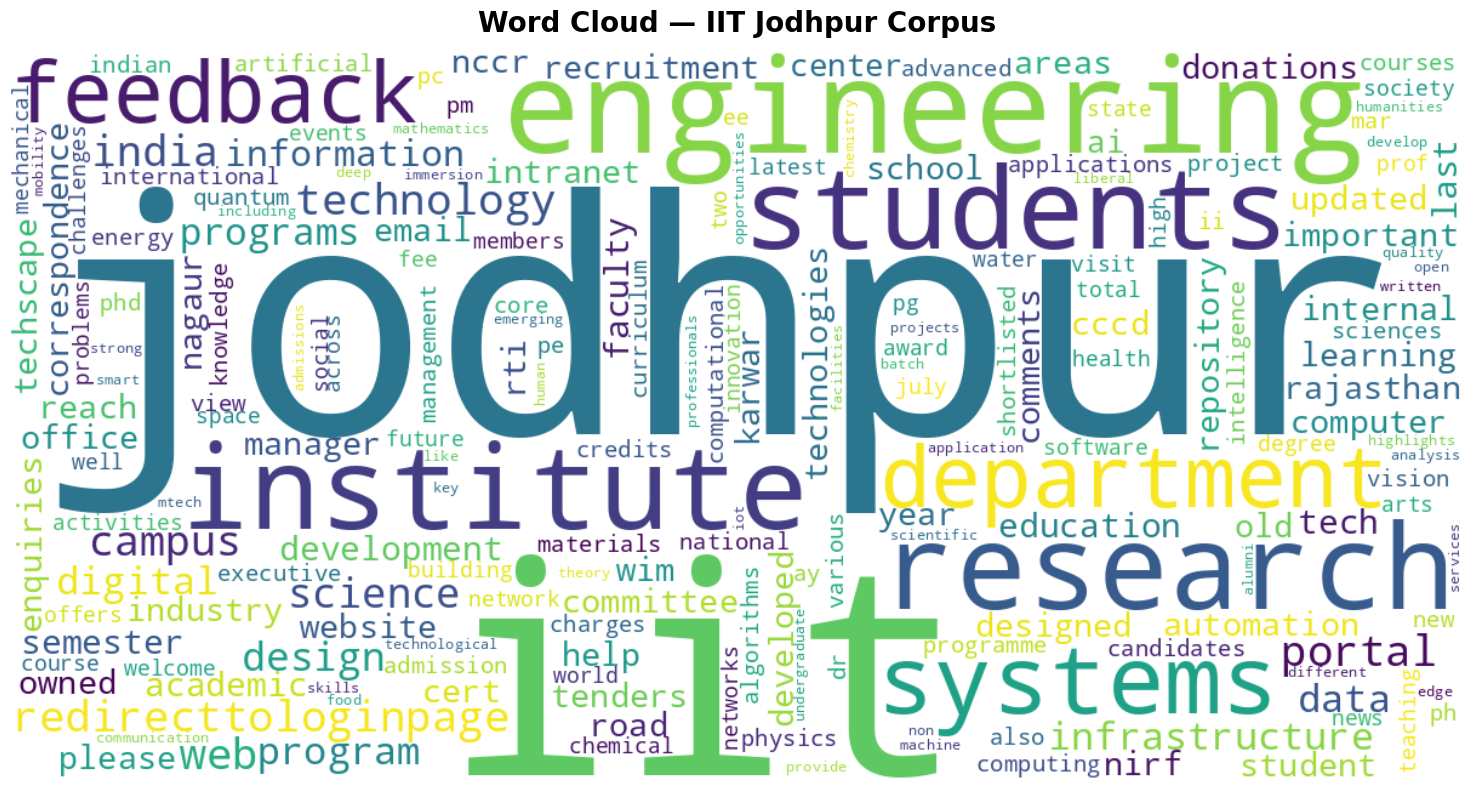

✅ Saved: wordcloud.png


In [8]:
# Generate and save Word Cloud (Task-1 visualization requirement)

print("  Generating Word Cloud...")

# Build frequency dict from vocab
freq_dict = dict(vocab.most_common(300))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=200,
    collocations=False
)
wc.generate_from_frequencies(freq_dict)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — IIT Jodhpur Corpus", fontsize=20, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: wordcloud.png")

In [9]:
# Word2Vec implementation FROM SCRATCH
# Implements both CBOW and Skip-gram with Negative Sampling using NumPy only.

class Word2VecScratch:
    """
    Word2Vec trained from scratch.
    Supports:
      - model_type: 'cbow' or 'skipgram'
      - Negative Sampling for efficient training
      - Configurable: embedding_dim, window_size, n_negative, learning_rate, epochs
    """

    def __init__(self, sentences, embedding_dim=100, window_size=5,
                 model_type='skipgram', n_negative=5, learning_rate=0.025,
                 epochs=5, min_count=2):
        self.sentences      = sentences
        self.embedding_dim  = embedding_dim
        self.window_size    = window_size
        self.model_type     = model_type   # 'cbow' or 'skipgram'
        self.n_negative     = n_negative   # negative samples per positive pair
        self.learning_rate  = learning_rate
        self.epochs         = epochs
        self.min_count      = min_count

        # Build vocabulary
        self._build_vocab()

        # Initialize weight matrices (small random values)
        # W_in  : input  embeddings  (vocab_size × embedding_dim)
        # W_out : output embeddings  (vocab_size × embedding_dim)
        self.W_in  = np.random.uniform(-0.5 / embedding_dim,
                                        0.5 / embedding_dim,
                                        (self.vocab_size, embedding_dim))
        self.W_out = np.zeros((self.vocab_size, embedding_dim))

    # ------------------------------------------------------------------
    # Vocabulary building
    # ------------------------------------------------------------------

    def _build_vocab(self):
        """
        Builds word-to-index and index-to-word mappings.
        Filters words below min_count.
        Also builds a unigram distribution for negative sampling.
        """
        counter = Counter(
            word for sent in self.sentences for word in sent
        )

        # Filter rare words
        filtered = {w: c for w, c in counter.items() if c >= self.min_count}

        self.word2idx = {w: i for i, w in enumerate(filtered.keys())}
        self.idx2word = {i: w for w, i in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

        # Unigram distribution raised to 3/4 power (standard Word2Vec trick)
        counts = np.array([filtered[self.idx2word[i]]
                           for i in range(self.vocab_size)], dtype=float)
        counts = counts ** 0.75
        self.neg_sampling_dist = counts / counts.sum()  # normalized probability

        print(f"  Vocabulary size (min_count={self.min_count}): {self.vocab_size}")

    # ------------------------------------------------------------------
    # Negative sampling helper
    # ------------------------------------------------------------------

    def _get_negative_samples(self, target_idx, k):
        """
        Draws k negative sample indices using the unigram^0.75 distribution.
        Ensures the target word itself is not included.
        """
        neg_samples = []
        while len(neg_samples) < k:
            sample = np.random.choice(self.vocab_size, p=self.neg_sampling_dist)
            if sample != target_idx:
                neg_samples.append(sample)
        return neg_samples

    # ------------------------------------------------------------------
    # Sigmoid activation
    # ------------------------------------------------------------------

    @staticmethod
    def _sigmoid(x):
        # Clipping prevents overflow in exp
        return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))

    # ------------------------------------------------------------------
    # Skip-gram with Negative Sampling — one training pair
    # ------------------------------------------------------------------

    def _train_skipgram_pair(self, center_idx, context_idx):
        """
        Trains one (center, context) positive pair + n_negative negative pairs.
        Updates W_in and W_out in-place.
        Returns the loss for this pair.
        """
        lr = self.learning_rate

        # Positive sample
        neg_samples = self._get_negative_samples(context_idx, self.n_negative)
        all_targets  = [context_idx] + neg_samples
        all_labels   = [1] + [0] * self.n_negative

        # Input embedding (center word)
        h = self.W_in[center_idx].copy()   # shape: (embedding_dim,)

        grad_h = np.zeros(self.embedding_dim)  # accumulated gradient for center
        loss = 0.0

        for t_idx, label in zip(all_targets, all_labels):
            # Score: dot product of center embedding and target embedding
            score = np.dot(h, self.W_out[t_idx])
            prob  = self._sigmoid(score)

            # Binary cross-entropy gradient
            error = prob - label
            loss  -= (label * np.log(prob + 1e-10) +
                      (1 - label) * np.log(1 - prob + 1e-10))

            # Gradient for W_out[t_idx]
            grad_h += error * self.W_out[t_idx]
            self.W_out[t_idx] -= lr * error * h

        # Update center word embedding
        self.W_in[center_idx] -= lr * grad_h
        return loss

    # ------------------------------------------------------------------
    # CBOW with Negative Sampling — one training instance
    # ------------------------------------------------------------------

    def _train_cbow_instance(self, context_indices, center_idx):
        """
        Trains one CBOW instance: context → center.
        Uses the mean of context embeddings as hidden layer.
        """
        if not context_indices:
            return 0.0

        lr = self.learning_rate

        # Hidden layer: mean of context word embeddings
        h = np.mean(self.W_in[context_indices], axis=0)  # shape: (embedding_dim,)

        neg_samples = self._get_negative_samples(center_idx, self.n_negative)
        all_targets  = [center_idx] + neg_samples
        all_labels   = [1] + [0] * self.n_negative

        grad_h = np.zeros(self.embedding_dim)
        loss = 0.0

        for t_idx, label in zip(all_targets, all_labels):
            score = np.dot(h, self.W_out[t_idx])
            prob  = self._sigmoid(score)
            error = prob - label
            loss  -= (label * np.log(prob + 1e-10) +
                      (1 - label) * np.log(1 - prob + 1e-10))

            grad_h += error * self.W_out[t_idx]
            self.W_out[t_idx] -= lr * error * h

        # Distribute gradient equally to each context word embedding
        grad_per_context = grad_h / len(context_indices)
        for c_idx in context_indices:
            self.W_in[c_idx] -= lr * grad_per_context

        return loss

    # ------------------------------------------------------------------
    # Main training loop
    # ------------------------------------------------------------------

    def train(self):
        """
        Trains the Word2Vec model for self.epochs epochs.
        Prints loss after each epoch.
        """
        print(f"\n Training {self.model_type.upper()} (scratch) | "
              f"dim={self.embedding_dim}, window={self.window_size}, "
              f"neg={self.n_negative}, epochs={self.epochs}")

        for epoch in range(self.epochs):
            total_loss = 0.0
            pair_count = 0

            # Shuffle sentences each epoch for better generalization
            random.shuffle(self.sentences)

            for sent in self.sentences:
                # Convert words to indices; skip unknown words
                indices = [self.word2idx[w] for w in sent if w in self.word2idx]
                if len(indices) < 2:
                    continue

                for i, center_idx in enumerate(indices):
                    # Dynamic window: randomly sample window size up to max
                    actual_window = random.randint(1, self.window_size)
                    context_indices = (
                        indices[max(0, i - actual_window):i] +
                        indices[i + 1: i + actual_window + 1]
                    )

                    if self.model_type == 'skipgram':
                        # Skip-gram: predict each context word from center
                        for c_idx in context_indices:
                            loss = self._train_skipgram_pair(center_idx, c_idx)
                            total_loss += loss
                            pair_count += 1

                    elif self.model_type == 'cbow':
                        # CBOW: predict center word from all context words
                        loss = self._train_cbow_instance(context_indices, center_idx)
                        total_loss += loss
                        pair_count += 1

            avg_loss = total_loss / max(pair_count, 1)
            print(f"  Epoch {epoch+1}/{self.epochs} — Avg Loss: {avg_loss:.4f} "
                  f"({pair_count:,} pairs)")

        print(f" Training complete.")

    # ------------------------------------------------------------------
    # Inference: cosine similarity & nearest neighbors
    # ------------------------------------------------------------------

    def get_vector(self, word):
        """Returns the embedding vector for a word."""
        if word not in self.word2idx:
            raise KeyError(f"Word '{word}' not in vocabulary.")
        return self.W_in[self.word2idx[word]]

    def cosine_similarity(self, v1, v2):
        """Cosine similarity between two vectors."""
        n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if n1 == 0 or n2 == 0:
            return 0.0
        return float(np.dot(v1, v2) / (n1 * n2))

    def most_similar(self, word, topn=5):
        """
        Returns top-n most similar words by cosine similarity.
        """
        if word not in self.word2idx:
            print(f"  '{word}' not in vocabulary.")
            return []

        query_vec = self.get_vector(word)
        scores = []
        for w, idx in self.word2idx.items():
            if w == word:
                continue
            sim = self.cosine_similarity(query_vec, self.W_in[idx])
            scores.append((w, sim))

        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:topn]

    def analogy(self, pos1, neg1, pos2, topn=5):
        """
        Solves analogy: pos1 is to neg1 as pos2 is to ?
        Formula: result = vec(pos2) - vec(neg1) + vec(pos1)
        """
        try:
            result_vec = (self.get_vector(pos2)
                          - self.get_vector(neg1)
                          + self.get_vector(pos1))
        except KeyError as e:
            print(f"  Analogy skipped — {e}")
            return []

        exclude = {pos1, neg1, pos2}
        scores = []
        for w, idx in self.word2idx.items():
            if w in exclude:
                continue
            sim = self.cosine_similarity(result_vec, self.W_in[idx])
            scores.append((w, sim))

        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:topn]

print(" Word2VecScratch class defined.")

✅ Word2VecScratch class defined.


In [10]:
# Train both CBOW and Skip-gram scratch models
# Hyperparameters are chosen based on standard Word2Vec practice for small corpora.
# We train two variants each: one with smaller dim and one with larger,
# to satisfy the "experiment with embedding dimension, window, negative samples" requirement.
import os
os.environ["OMP_NUM_THREADS"] = "4"   # use multiple CPU cores for numpy
# Load processed sentences
with open("processed_corpus.pkl", "rb") as f:
    all_sentences = pickle.load(f)

print(f" Loaded {len(all_sentences)} sentences for training.\n")

# ---------------------------------------------------------------
# Skip-gram Model — Config A (main model)
# ---------------------------------------------------------------
print("=" * 60)
print("TRAINING: Skip-gram Model A (dim=100, window=5, neg=5)")
print("=" * 60)
sg_model_A = Word2VecScratch(
    sentences       = all_sentences,
    embedding_dim   = 100,     # standard embedding size
    window_size     = 5,       # context window
    model_type      = 'skipgram',
    n_negative      = 5,       # negative samples per positive pair
    learning_rate   = 0.025,
    epochs          = 15,
    min_count       = 2
)
sg_model_A.train()

# ---------------------------------------------------------------
# Skip-gram Model — Config B (different hyperparams for comparison)
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("TRAINING: Skip-gram Model B (dim=50, window=3, neg=10)")
print("=" * 60)
sg_model_B = Word2VecScratch(
    sentences       = all_sentences,
    embedding_dim   = 50,
    window_size     = 3,
    model_type      = 'skipgram',
    n_negative      = 10,
    learning_rate   = 0.025,
    epochs          = 15,
    min_count       = 2
)
sg_model_B.train()

# ---------------------------------------------------------------
# CBOW Model — Config A (main model)
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("TRAINING: CBOW Model A (dim=100, window=5, neg=5)")
print("=" * 60)
cbow_model_A = Word2VecScratch(
    sentences       = all_sentences,
    embedding_dim   = 100,
    window_size     = 5,
    model_type      = 'cbow',
    n_negative      = 5,
    learning_rate   = 0.025,
    epochs          = 15,
    min_count       = 2
)
cbow_model_A.train()

# ---------------------------------------------------------------
# CBOW Model — Config B
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("TRAINING: CBOW Model B (dim=50, window=3, neg=10)")
print("=" * 60)
cbow_model_B = Word2VecScratch(
    sentences       = all_sentences,
    embedding_dim   = 50,
    window_size     = 3,
    model_type      = 'cbow',
    n_negative      = 10,
    learning_rate   = 0.025,
    epochs          = 15,
    min_count       = 2
)
cbow_model_B.train()

print("\n All 4 scratch models trained successfully.")

📦 Loaded 1406 sentences for training.

TRAINING: Skip-gram Model A (dim=100, window=5, neg=5)
  Vocabulary size (min_count=2): 2157

🚀 Training SKIPGRAM (scratch) | dim=100, window=5, neg=5, epochs=15
  Epoch 1/15 — Avg Loss: 4.1028 (99,592 pairs)
  Epoch 2/15 — Avg Loss: 2.9609 (100,086 pairs)
  Epoch 3/15 — Avg Loss: 2.3492 (99,598 pairs)
  Epoch 4/15 — Avg Loss: 2.1777 (100,136 pairs)
  Epoch 5/15 — Avg Loss: 2.0799 (100,153 pairs)
  Epoch 6/15 — Avg Loss: 1.9978 (99,641 pairs)
  Epoch 7/15 — Avg Loss: 1.9269 (99,924 pairs)
  Epoch 8/15 — Avg Loss: 1.8584 (99,927 pairs)
  Epoch 9/15 — Avg Loss: 1.7956 (99,771 pairs)
  Epoch 10/15 — Avg Loss: 1.7456 (99,710 pairs)
  Epoch 11/15 — Avg Loss: 1.6910 (99,766 pairs)
  Epoch 12/15 — Avg Loss: 1.6457 (99,375 pairs)
  Epoch 13/15 — Avg Loss: 1.5892 (99,380 pairs)
  Epoch 14/15 — Avg Loss: 1.5457 (99,996 pairs)
  Epoch 15/15 — Avg Loss: 1.5024 (99,766 pairs)
✅ Training complete.

TRAINING: Skip-gram Model B (dim=50, window=3, neg=10)
  Vocabu

In [11]:
# Train Gensim Word2Vec models for comparison with scratch models.
# The assignment says "from scratch AND compared with existing ones."
# Gensim is the well-optimized library implementation.

print(" Training Gensim models for comparison...\n")

# Gensim Skip-gram (sg=1) with negative sampling (ns=1)
gensim_sg = GensimWord2Vec(
    sentences   = all_sentences,
    vector_size = 100,        # embedding dimension
    window      = 5,          # context window
    sg          = 1,          # 1 = Skip-gram, 0 = CBOW
    negative    = 5,          # number of negative samples
    min_count   = 2,
    epochs      = 15,
    workers     = 4           # parallel threads
)
print(" Gensim Skip-gram trained.")

# Gensim CBOW (sg=0)
gensim_cbow = GensimWord2Vec(
    sentences   = all_sentences,
    vector_size = 100,
    window      = 5,
    sg          = 0,          # CBOW
    negative    = 5,
    min_count   = 2,
    epochs      = 15,
    workers     = 4
)
print(" Gensim CBOW trained.")

# Save Gensim models to disk
gensim_sg.save("gensim_skipgram.model")
gensim_cbow.save("gensim_cbow.model")
print("\n Gensim models saved.")

🔧 Training Gensim models for comparison...

✅ Gensim Skip-gram trained.
✅ Gensim CBOW trained.

💾 Gensim models saved.


In [12]:
# Semantic Analysis — Task 3
# Reports top-5 nearest neighbors for required words using cosine similarity.
# Compares scratch vs Gensim results.

QUERY_WORDS = ["research", "student", "phd", "exam", "faculty"]
# Note: 'exam' appears twice in the assignment (likely a typo); I included 'faculty' as 5th.

def safe_most_similar_gensim(model, word, topn=5):
    """Wrapper to handle OOV words in Gensim."""
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        return [(f"'{word}' not in vocab", 0.0)]

print("=" * 70)
print(" SEMANTIC ANALYSIS — Top-5 Nearest Neighbors")
print("=" * 70)

for word in QUERY_WORDS:
    print(f"\n Word: '{word}'")
    print("-" * 50)

    # Scratch Skip-gram
    print("  [Scratch Skip-gram A]")
    sg_neighbors = sg_model_A.most_similar(word, topn=5)
    for rank, (w, score) in enumerate(sg_neighbors, 1):
        print(f"    {rank}. {w:<20} (cosine: {score:.4f})")

    # Scratch CBOW
    print("  [Scratch CBOW A]")
    cbow_neighbors = cbow_model_A.most_similar(word, topn=5)
    for rank, (w, score) in enumerate(cbow_neighbors, 1):
        print(f"    {rank}. {w:<20} (cosine: {score:.4f})")

    # Gensim Skip-gram
    print("  [Gensim Skip-gram]")
    g_sg = safe_most_similar_gensim(gensim_sg, word, topn=5)
    for rank, (w, score) in enumerate(g_sg, 1):
        print(f"    {rank}. {w:<20} (cosine: {score:.4f})")

    # Gensim CBOW
    print("  [Gensim CBOW]")
    g_cbow = safe_most_similar_gensim(gensim_cbow, word, topn=5)
    for rank, (w, score) in enumerate(g_cbow, 1):
        print(f"    {rank}. {w:<20} (cosine: {score:.4f})")

📊 SEMANTIC ANALYSIS — Top-5 Nearest Neighbors

🔍 Word: 'research'
--------------------------------------------------
  [Scratch Skip-gram A]
    1. subhasish            (cosine: 0.5328)
    2. member               (cosine: 0.5231)
    3. instrumentation      (cosine: 0.5172)
    4. laboratories         (cosine: 0.5082)
    5. excellence           (cosine: 0.5022)
  [Scratch CBOW A]
    1. development          (cosine: 0.9724)
    2. education            (cosine: 0.9715)
    3. train                (cosine: 0.9643)
    4. foster               (cosine: 0.9618)
    5. students             (cosine: 0.9543)
  [Gensim Skip-gram]
    1. excellence           (cosine: 0.9313)
    2. teaching             (cosine: 0.8916)
    3. laboratories         (cosine: 0.8548)
    4. interests            (cosine: 0.8538)
    5. involved             (cosine: 0.8500)
  [Gensim CBOW]
    1. quality              (cosine: 0.9954)
    2. students             (cosine: 0.9952)
    3. innovation           (cosine: 0

In [13]:
# Analogy experiments — fully data-driven
# Instead of hardcoding words, we:
#   1. Print the actual top vocabulary words so you can SEE what's available
#   2. Auto-discover candidate analogy words by looking for semantically
#      related clusters in the real vocabulary
#   3. Run analogies only using words confirmed present in ALL models

print("=" * 70)
print(" ANALOGY EXPERIMENTS")
print("=" * 70)

# ── Step 1: Show actual top vocabulary so analogies are grounded in data ──
print("\n Top 100 words in corpus vocabulary (use these for analogies):")
print("─" * 70)
top_100 = [w for w, _ in vocab.most_common(100)]
# Print in a readable grid (10 per row)
for i in range(0, len(top_100), 10):
    print("  " + "  ".join(f"{w:<12}" for w in top_100[i:i+10]))

# ── Step 2: Find which vocabulary words belong to key semantic categories ──
# These are CANDIDATE sets — we check actual vocab membership before using them

CANDIDATE_GROUPS = {
    "degree_programs" : ["btech", "mtech", "msc", "phd", "ug", "pg",
                         "undergraduate", "postgraduate", "doctoral",
                         "bachelor", "master", "degree", "program"],

    "departments"     : ["cse", "ee", "me", "ce", "physics", "chemistry",
                         "mathematics", "bioscience", "humanities",
                         "computer", "electrical", "mechanical", "civil"],

    "academic_roles"  : ["student", "faculty", "professor", "researcher",
                         "scholar", "staff", "supervisor", "advisor"],

    "academic_work"   : ["thesis", "dissertation", "research", "project",
                         "publication", "paper", "experiment", "study"],

    "assessment"      : ["exam", "examination", "grade", "semester",
                         "course", "credit", "attendance", "result"],
}

# Check which candidates actually exist in scratch SG vocab (primary model)
print("\n\n Candidate analogy words found in vocabulary:")
print("─" * 70)
confirmed = {}
for group, candidates in CANDIDATE_GROUPS.items():
    found = [w for w in candidates if w in sg_model_A.word2idx]
    confirmed[group] = found
    print(f"  {group:<20}: {found}")


# ── Step 3: Auto-build analogies from confirmed words ─────────────────
# Build analogy pairs only if BOTH words in a pair exist in vocab.
# Format: (pos1, neg1, pos2, description)

def make_analogy_if_possible(w1, w2, w3, desc, vocab_set):
    """Returns analogy tuple only if all 3 words are in vocab."""
    if all(w in vocab_set for w in [w1, w2, w3]):
        return (w1, w2, w3, desc)
    return None

sg_vocab = set(sg_model_A.word2idx.keys())

# Building analogies from confirmed vocabulary
analogy_candidates = [
    # Degree level analogies
    make_analogy_if_possible("undergraduate", "bachelor",  "postgraduate",
                              "undergraduate:bachelor :: postgraduate:?", sg_vocab),
    make_analogy_if_possible("btech",  "undergraduate", "mtech",
                              "BTech:undergraduate :: MTech:?",           sg_vocab),
    make_analogy_if_possible("ug",     "btech",         "pg",
                              "UG:BTech :: PG:?",                         sg_vocab),
    make_analogy_if_possible("phd",    "thesis",        "mtech",
                              "PhD:thesis :: MTech:?",                    sg_vocab),
    make_analogy_if_possible("phd",    "doctoral",      "mtech",
                              "PhD:doctoral :: MTech:?",                  sg_vocab),

    # Role analogies
    make_analogy_if_possible("professor", "research",   "student",
                              "professor:research :: student:?",          sg_vocab),
    make_analogy_if_possible("faculty",   "supervisor",  "student",
                              "faculty:supervisor :: student:?",          sg_vocab),

    # Department analogies
    make_analogy_if_possible("cse",    "computer",      "ee",
                              "CSE:computer :: EE:?",                     sg_vocab),
    make_analogy_if_possible("cse",    "computer",      "me",
                              "CSE:computer :: ME:?",                     sg_vocab),
    make_analogy_if_possible("physics","science",       "mathematics",
                              "physics:science :: mathematics:?",         sg_vocab),

    # Academic work analogies
    make_analogy_if_possible("exam",   "semester",      "thesis",
                              "exam:semester :: thesis:?",                sg_vocab),
    make_analogy_if_possible("research","publication",  "study",
                              "research:publication :: study:?",          sg_vocab),
]

# Filter out None entries (where words were not in vocab)
analogies = [a for a in analogy_candidates if a is not None]

print(f"\n\n {len(analogies)} valid analogies auto-selected from actual vocabulary.")

if len(analogies) == 0:
    print("\n  No analogies could be formed from current vocabulary.")
    print("   This means the corpus is too small or key words were filtered.")
    print("   Consider: adding more PDFs, reducing min_count in Block 9,")
    print("   or removing some words from EXTRA_STOPS in Block 6.")
else:
    # ── Step 4: Run analogies on all models ───────────────────────────
    def run_analogy(model_obj, model_name, pos1, neg1, pos2, description):
        print(f"\n  [{model_name}]")
        results = model_obj.analogy(pos1, neg1, pos2, topn=5)
        if results:
            for rank, (w, score) in enumerate(results, 1):
                print(f"    {rank}. {w:<20} ({score:.4f})")
        else:
            print("    (No results)")

    def run_analogy_gensim(model, model_name, pos1, neg1, pos2, description):
        print(f"\n  [{model_name}]")
        try:
            results = model.wv.most_similar(
                positive=[pos1, pos2], negative=[neg1], topn=5)
            for rank, (w, score) in enumerate(results, 1):
                print(f"    {rank}. {w:<20} ({score:.4f})")
        except KeyError as e:
            print(f"    (Skipped — {e} not in vocab)")

    for pos1, neg1, pos2, desc in analogies:
        print("\n" + "─" * 60)
        print(f"  Analogy: {desc}")
        print("─" * 60)
        run_analogy(sg_model_A,    "Scratch Skip-gram A", pos1, neg1, pos2, desc)
        run_analogy(cbow_model_A,  "Scratch CBOW A",      pos1, neg1, pos2, desc)
        run_analogy_gensim(gensim_sg,   "Gensim Skip-gram",   pos1, neg1, pos2, desc)
        run_analogy_gensim(gensim_cbow, "Gensim CBOW",         pos1, neg1, pos2, desc)

🔗 ANALOGY EXPERIMENTS

📋 Top 100 words in corpus vocabulary (use these for analogies):
──────────────────────────────────────────────────────────────────────
  jodhpur       iit           engineering   research      institute     students      systems       department    feedback      redirecttologinpage
  portal        web           technology    india         campus        science       design        digital       infrastructure  data        
  program       programs      information   academic      development   semester      last          tech          education     faculty     
  learning      committee     student       designed      nagaur        important     automation    rajasthan     please        email       
  website       reach         internal      developed     help          road          computer      recruitment   nirf          karwar      
  comments      technologies  year          areas         office        school        industry      cccd          correspondence

📊 Generating PCA plots...


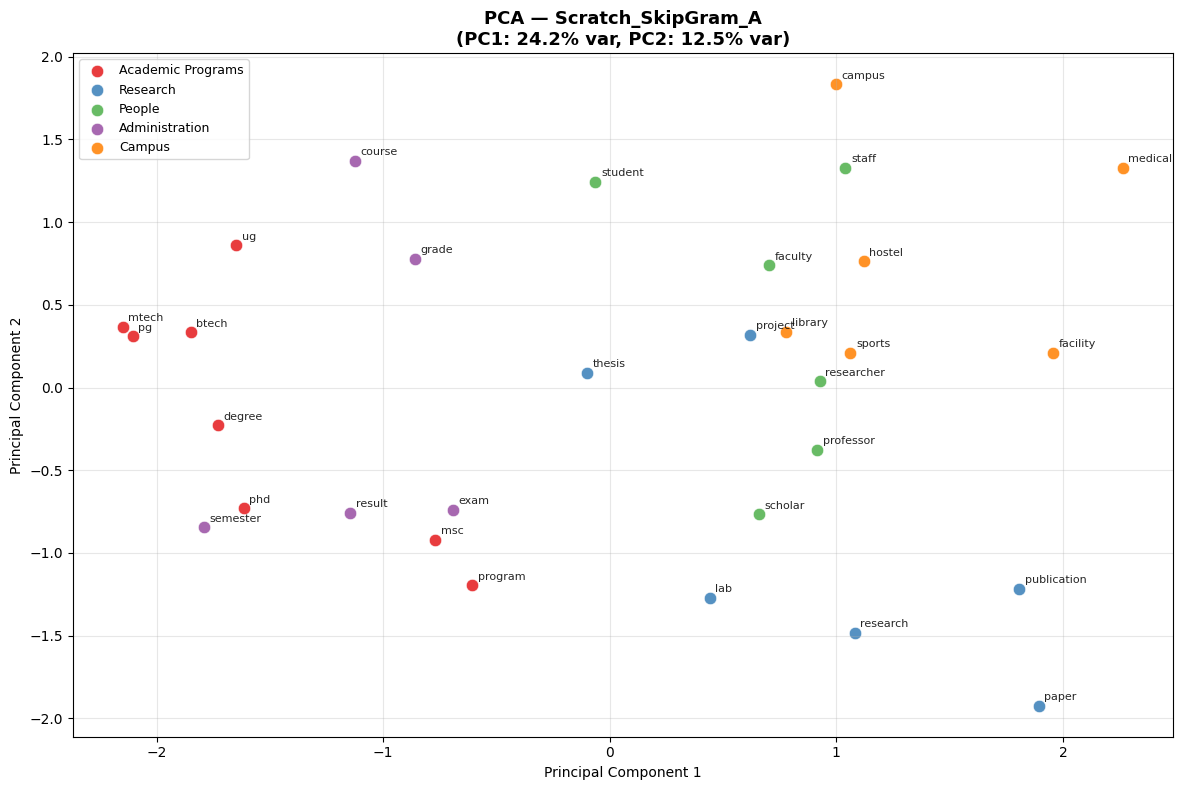

  💾 Saved: pca_Scratch_SkipGram_A.png


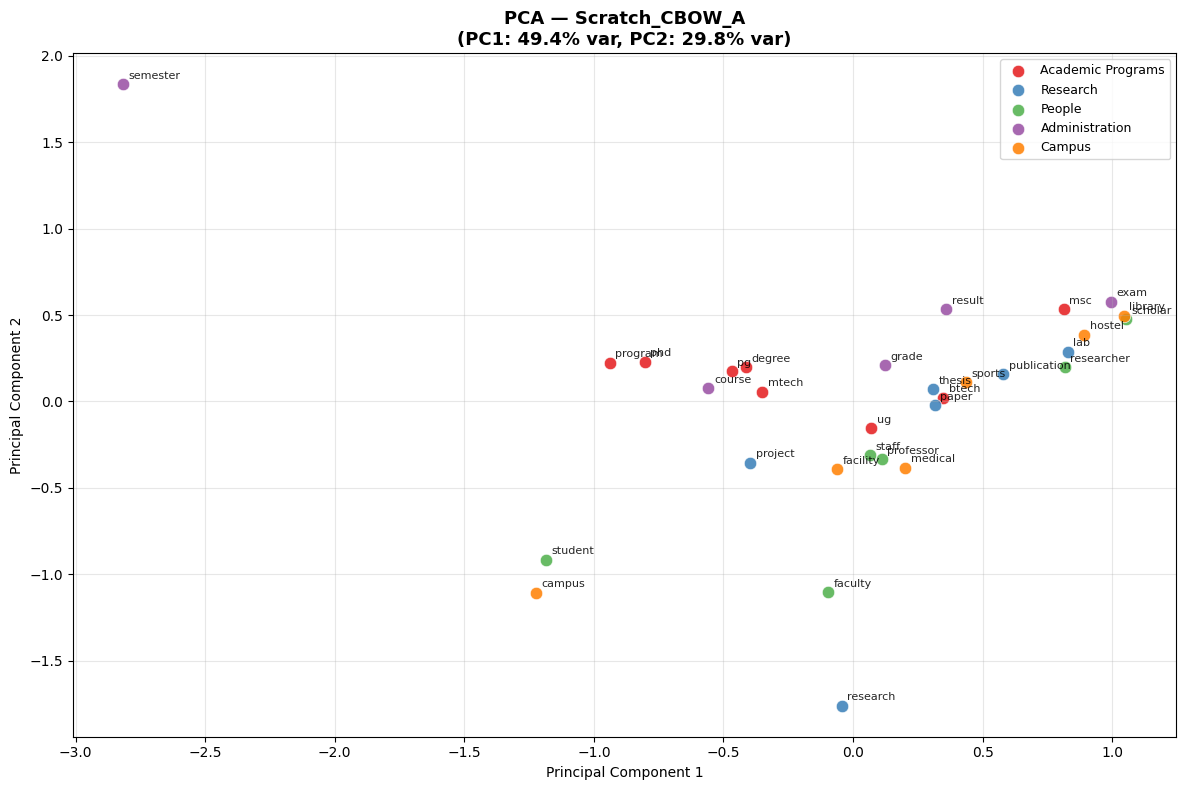

  💾 Saved: pca_Scratch_CBOW_A.png


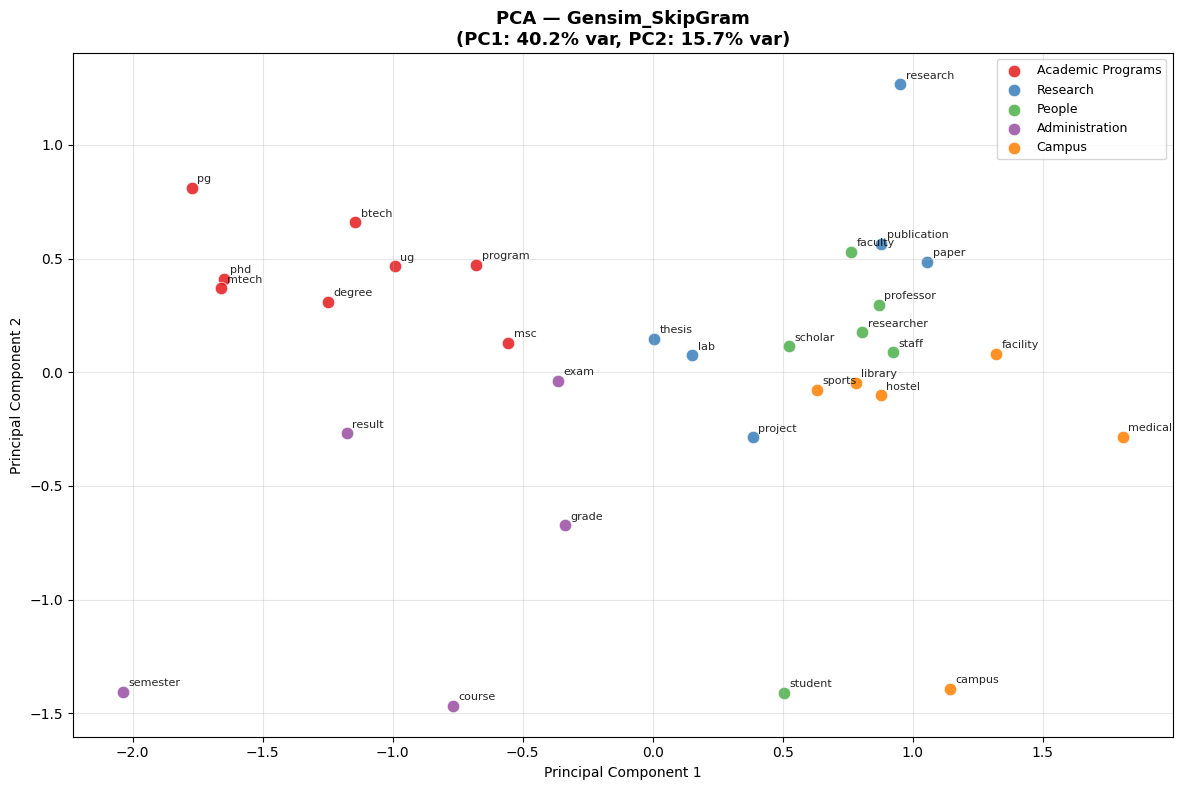

  💾 Saved: pca_Gensim_SkipGram.png


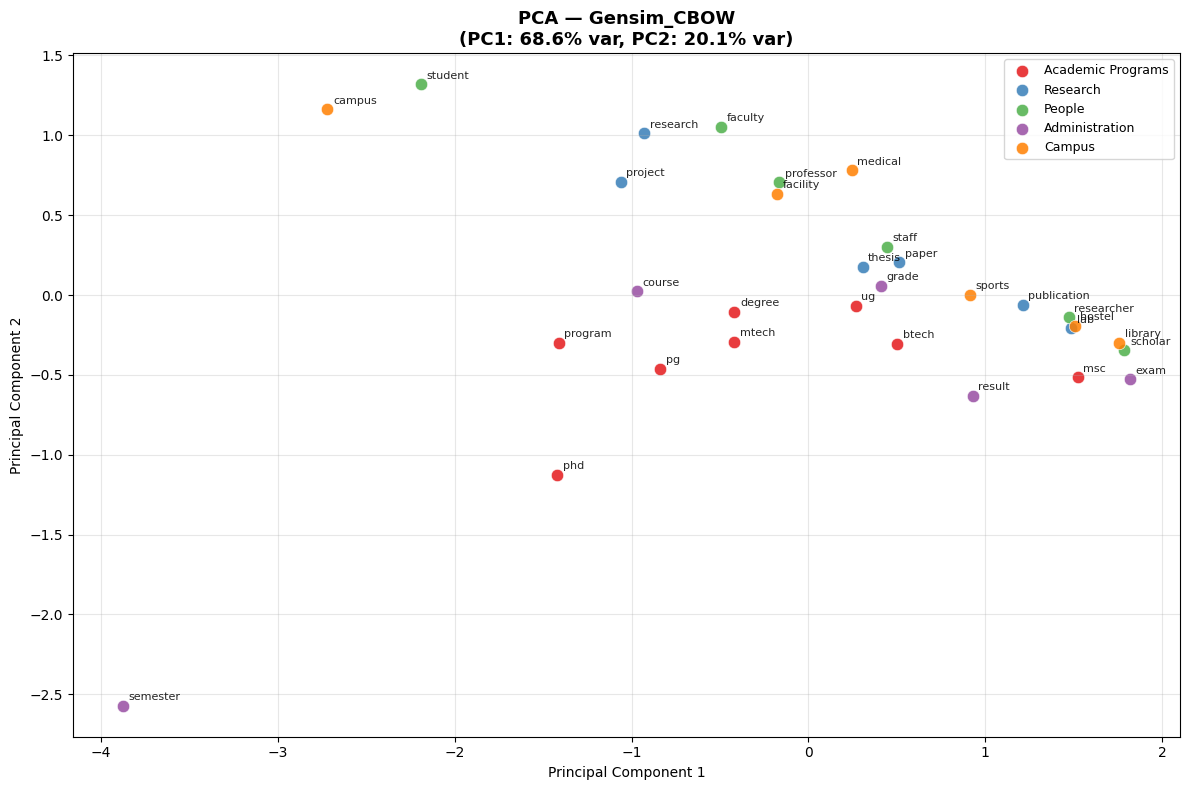

  💾 Saved: pca_Gensim_CBOW.png

✅ PCA plots complete.


In [14]:
# PCA 2D visualization of word embeddings — Task 4
# Visualizes clusters of semantically related words.
# Compares CBOW vs Skip-gram from BOTH scratch and Gensim models.

# Define word clusters to visualize
CLUSTER_WORDS = {
    "Academic Programs": ["ug", "pg", "phd", "btech", "mtech", "msc", "degree", "program"],
    "Research":          ["research", "thesis", "publication", "project", "lab", "paper"],
    "People":            ["student", "faculty", "professor", "staff", "scholar", "researcher"],
    "Administration":    ["exam", "grade", "result", "attendance", "course", "semester"],
    "Campus":            ["library", "hostel", "campus", "sports", "medical", "facility"],
}

# Flatten into list with cluster labels
words_list   = []
cluster_list = []
for cluster_name, words in CLUSTER_WORDS.items():
    for w in words:
        words_list.append(w)
        cluster_list.append(cluster_name)

COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
cluster_names = list(CLUSTER_WORDS.keys())


def get_vectors_for_words(model_obj, words):
    """
    Extracts embedding vectors for a list of words from scratch model.
    Returns (valid_words, vectors) — skips OOV words.
    """
    valid_words, vectors = [], []
    for w in words:
        if w in model_obj.word2idx:
            valid_words.append(w)
            vectors.append(model_obj.W_in[model_obj.word2idx[w]])
    return valid_words, np.array(vectors)


def get_vectors_gensim(model, words):
    """Same but for Gensim model."""
    valid_words, vectors = [], []
    for w in words:
        if w in model.wv:
            valid_words.append(w)
            vectors.append(model.wv[w])
    return valid_words, np.array(vectors)


def plot_pca(model_obj, model_name, words_list, cluster_list, is_gensim=False):
    """
    Plots PCA 2D projection of word embeddings colored by cluster.
    """
    # Get vectors
    if is_gensim:
        valid_w, vecs = get_vectors_gensim(model_obj, words_list)
    else:
        valid_w, vecs = get_vectors_for_words(model_obj, words_list)

    if len(vecs) < 5:
        print(f"  Not enough vocab overlap for '{model_name}', skipping.")
        return

    # Map valid words back to their clusters
    word_to_cluster = dict(zip(words_list, cluster_list))
    valid_clusters  = [word_to_cluster.get(w, "Other") for w in valid_w]

    # PCA to 2D
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    for idx, cname in enumerate(cluster_names):
        mask = [i for i, c in enumerate(valid_clusters) if c == cname]
        if mask:
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                c=COLORS[idx % len(COLORS)],
                label=cname, s=80, alpha=0.85, edgecolors='white', linewidths=0.5
            )
            for m in mask:
                ax.annotate(
                    valid_w[m],
                    (coords[m, 0], coords[m, 1]),
                    fontsize=8, alpha=0.85,
                    xytext=(4, 4), textcoords='offset points'
                )

    var_exp = pca.explained_variance_ratio_
    ax.set_title(
        f"PCA — {model_name}\n"
        f"(PC1: {var_exp[0]*100:.1f}% var, PC2: {var_exp[1]*100:.1f}% var)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"pca_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   Saved: {fname}")


print(" Generating PCA plots...")

plot_pca(sg_model_A,   "Scratch_SkipGram_A",  words_list, cluster_list)
plot_pca(cbow_model_A, "Scratch_CBOW_A",       words_list, cluster_list)
plot_pca(gensim_sg,    "Gensim_SkipGram",      words_list, cluster_list, is_gensim=True)
plot_pca(gensim_cbow,  "Gensim_CBOW",          words_list, cluster_list, is_gensim=True)

print("\n PCA plots complete.")

📊 Generating t-SNE plots...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


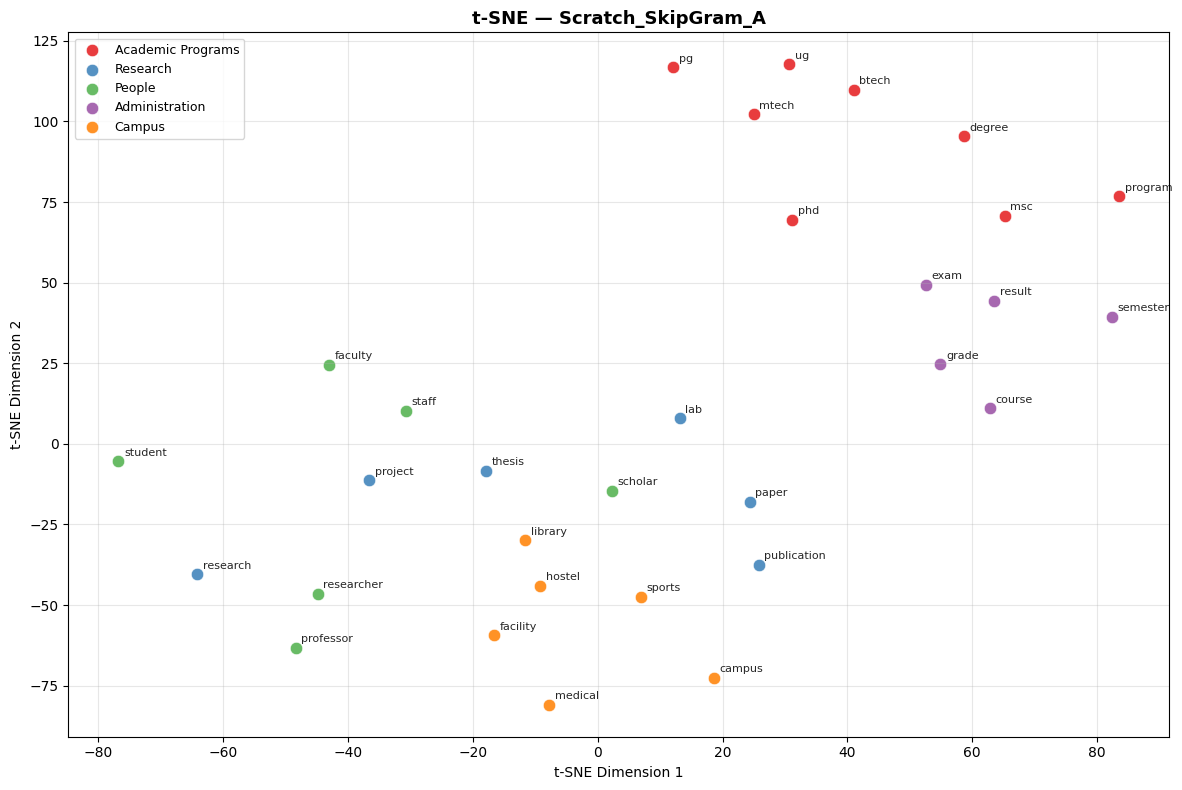

  💾 Saved: tsne_Scratch_SkipGram_A.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


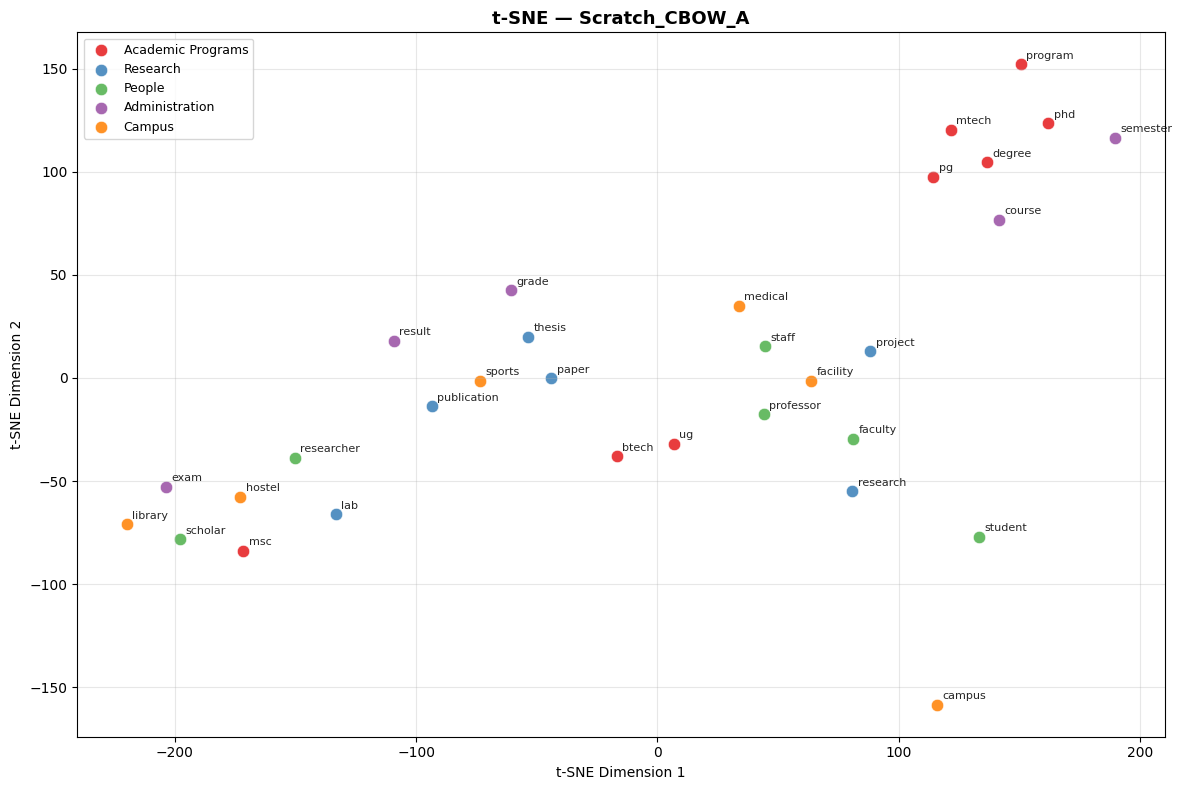

  💾 Saved: tsne_Scratch_CBOW_A.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


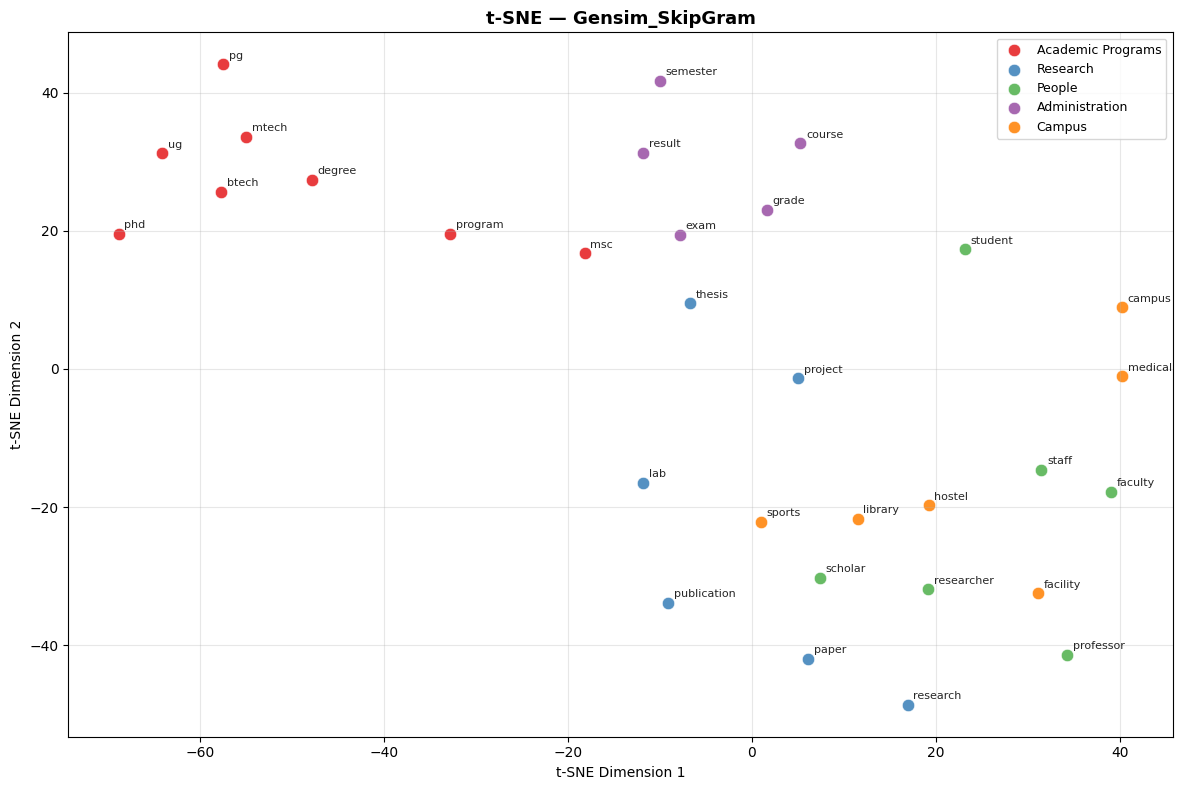

  💾 Saved: tsne_Gensim_SkipGram.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


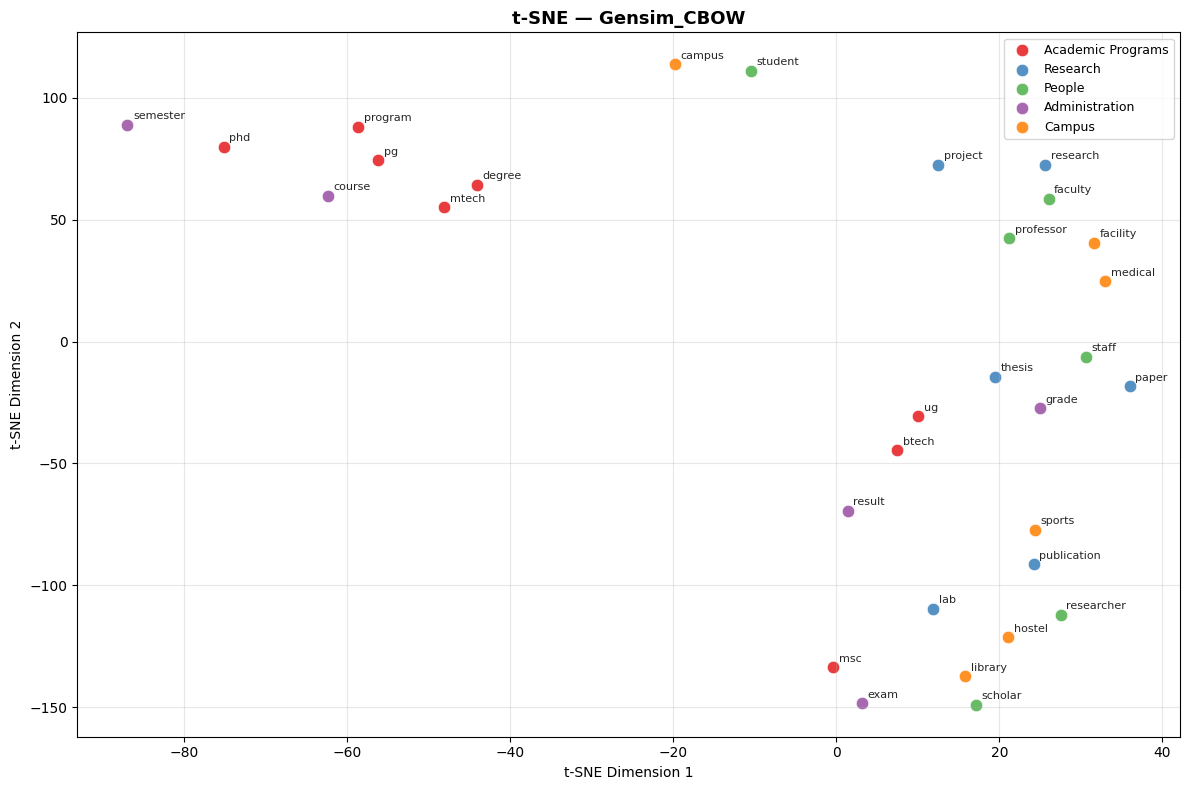

  💾 Saved: tsne_Gensim_CBOW.png

✅ t-SNE plots complete.


In [15]:
# t-SNE 2D visualization — alternative dimensionality reduction
# t-SNE often reveals tighter, more interpretable clusters than PCA.

def plot_tsne(model_obj, model_name, words_list, cluster_list, is_gensim=False):
    """
    Plots t-SNE 2D projection of word embeddings.
    """
    if is_gensim:
        valid_w, vecs = get_vectors_gensim(model_obj, words_list)
    else:
        valid_w, vecs = get_vectors_for_words(model_obj, words_list)

    if len(vecs) < 5:
        print(f"   Not enough vocab overlap for '{model_name}', skipping.")
        return

    word_to_cluster = dict(zip(words_list, cluster_list))
    valid_clusters  = [word_to_cluster.get(w, "Other") for w in valid_w]

    # t-SNE — perplexity must be < n_samples
    perplexity = min(5, len(vecs) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, n_iter=1000, init='pca')
    coords = tsne.fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(12, 8))
    for idx, cname in enumerate(cluster_names):
        mask = [i for i, c in enumerate(valid_clusters) if c == cname]
        if mask:
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                c=COLORS[idx % len(COLORS)],
                label=cname, s=80, alpha=0.85, edgecolors='white', linewidths=0.5
            )
            for m in mask:
                ax.annotate(
                    valid_w[m],
                    (coords[m, 0], coords[m, 1]),
                    fontsize=8, alpha=0.85,
                    xytext=(4, 4), textcoords='offset points'
                )

    ax.set_title(f"t-SNE — {model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"tsne_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


print(" Generating t-SNE plots...")

plot_tsne(sg_model_A,   "Scratch_SkipGram_A",  words_list, cluster_list)
plot_tsne(cbow_model_A, "Scratch_CBOW_A",       words_list, cluster_list)
plot_tsne(gensim_sg,    "Gensim_SkipGram",      words_list, cluster_list, is_gensim=True)
plot_tsne(gensim_cbow,  "Gensim_CBOW",          words_list, cluster_list, is_gensim=True)

print("\n t-SNE plots complete.")

In [16]:
# Formal comparison table of all model configurations
# Reports similarity scores for key words across all 4 scratch models + 2 gensim models.
# This satisfies the "show results formally in the report" requirement of Task-2.

print("=" * 80)
print(" HYPERPARAMETER CONFIGURATION SUMMARY")
print("=" * 80)

configs = [
    ("Scratch Skip-gram A", "Skip-gram", "Scratch",  100, 5, 5),
    ("Scratch Skip-gram B", "Skip-gram", "Scratch",   50, 3, 10),
    ("Scratch CBOW A",      "CBOW",      "Scratch",  100, 5, 5),
    ("Scratch CBOW B",      "CBOW",      "Scratch",   50, 3, 10),
    ("Gensim Skip-gram",    "Skip-gram", "Gensim",   100, 5, 5),
    ("Gensim CBOW",         "CBOW",      "Gensim",   100, 5, 5),
]

header = f"{'Model':<25} {'Type':<12} {'Impl':<8} {'Dim':<5} {'Win':<5} {'Neg':<5}"
print(header)
print("─" * 65)
for name, mtype, impl, dim, win, neg in configs:
    print(f"{name:<25} {mtype:<12} {impl:<8} {dim:<5} {win:<5} {neg:<5}")

print("\n" + "=" * 80)
print(" TOP-1 NEAREST NEIGHBOR FOR KEY WORDS (across models)")
print("=" * 80)

models_to_check = [
    ("Scratch SG-A",  sg_model_A,   False),
    ("Scratch SG-B",  sg_model_B,   False),
    ("Scratch CBOW-A",cbow_model_A, False),
    ("Scratch CBOW-B",cbow_model_B, False),
    ("Gensim SG",     gensim_sg,    True),
    ("Gensim CBOW",   gensim_cbow,  True),
]

header2 = f"{'Word':<12}" + "".join(f"{m[0]:<20}" for m in models_to_check)
print(header2)
print("─" * (12 + 20 * len(models_to_check)))

for word in QUERY_WORDS:
    row = f"{word:<12}"
    for name, model, is_gensim in models_to_check:
        if is_gensim:
            try:
                top = model.wv.most_similar(word, topn=1)
                row += f"{top[0][0]:<20}"
            except:
                row += f"{'N/A':<20}"
        else:
            results = model.most_similar(word, topn=1)
            row += f"{results[0][0] if results else 'N/A':<20}"
    print(row)

📋 HYPERPARAMETER CONFIGURATION SUMMARY
Model                     Type         Impl     Dim   Win   Neg  
─────────────────────────────────────────────────────────────────
Scratch Skip-gram A       Skip-gram    Scratch  100   5     5    
Scratch Skip-gram B       Skip-gram    Scratch  50    3     10   
Scratch CBOW A            CBOW         Scratch  100   5     5    
Scratch CBOW B            CBOW         Scratch  50    3     10   
Gensim Skip-gram          Skip-gram    Gensim   100   5     5    
Gensim CBOW               CBOW         Gensim   100   5     5    

📋 TOP-1 NEAREST NEIGHBOR FOR KEY WORDS (across models)
Word        Scratch SG-A        Scratch SG-B        Scratch CBOW-A      Scratch CBOW-B      Gensim SG           Gensim CBOW         
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
research    subhasish           dey                 development         development         excellence         

In [17]:
# Save all deliverables to disk and print a summary.
# Files generated: cleaned corpus, model checkpoints, all visualizations.

import pickle

# Save scratch models as pickle files
print(" Saving scratch model checkpoints...")
with open("scratch_skipgram_A.pkl", "wb") as f:
    pickle.dump(sg_model_A, f)
with open("scratch_skipgram_B.pkl", "wb") as f:
    pickle.dump(sg_model_B, f)
with open("scratch_cbow_A.pkl", "wb") as f:
    pickle.dump(cbow_model_A, f)
with open("scratch_cbow_B.pkl", "wb") as f:
    pickle.dump(cbow_model_B, f)

# Save cleaned corpus as plain text (one sentence per line)
print(" Saving cleaned corpus text file...")
with open("cleaned_corpus.txt", "w", encoding="utf-8") as f:
    for sent in all_sentences:
        f.write(" ".join(sent) + "\n")

print("\n" + "=" * 60)
print(" ALL DELIVERABLES GENERATED")
print("=" * 60)

import os
deliverables = [
    "raw_corpus.json",
    "processed_corpus.pkl",
    "cleaned_corpus.txt",
    "wordcloud.png",
    "scratch_skipgram_A.pkl",
    "scratch_skipgram_B.pkl",
    "scratch_cbow_A.pkl",
    "scratch_cbow_B.pkl",
    "gensim_skipgram.model",
    "gensim_cbow.model",
]

for f in deliverables:
    exists = "✅" if os.path.exists(f) else "❌ MISSING"
    size = f"({os.path.getsize(f)/1024:.1f} KB)" if os.path.exists(f) else ""
    print(f"  {exists}  {f}  {size}")

# List all PNGs
pngs = [f for f in os.listdir(".") if f.endswith(".png")]
print(f"\n   Visualization files ({len(pngs)} total):")
for p in sorted(pngs):
    print(f"       ✅  {p}  ({os.path.getsize(p)/1024:.1f} KB)")

print("\n Download all files from the Colab sidebar (Files panel on the left).")
print("   Right-click any file → Download.")

💾 Saving scratch model checkpoints...
💾 Saving cleaned corpus text file...

✅ ALL DELIVERABLES GENERATED
  ✅  raw_corpus.json  (245.0 KB)
  ✅  processed_corpus.pkl  (226.9 KB)
  ✅  cleaned_corpus.txt  (178.3 KB)
  ✅  wordcloud.png  (1312.2 KB)
  ✅  scratch_skipgram_A.pkl  (3647.5 KB)
  ✅  scratch_skipgram_B.pkl  (1962.5 KB)
  ✅  scratch_cbow_A.pkl  (3647.5 KB)
  ✅  scratch_cbow_B.pkl  (1962.5 KB)
  ✅  gensim_skipgram.model  (1756.4 KB)
  ✅  gensim_cbow.model  (1756.4 KB)

  📊 Visualization files (9 total):
       ✅  pca_Gensim_CBOW.png  (110.8 KB)
       ✅  pca_Gensim_SkipGram.png  (110.7 KB)
       ✅  pca_Scratch_CBOW_A.png  (111.1 KB)
       ✅  pca_Scratch_SkipGram_A.png  (111.0 KB)
       ✅  tsne_Gensim_CBOW.png  (102.1 KB)
       ✅  tsne_Gensim_SkipGram.png  (100.4 KB)
       ✅  tsne_Scratch_CBOW_A.png  (101.2 KB)
       ✅  tsne_Scratch_SkipGram_A.png  (106.7 KB)
       ✅  wordcloud.png  (1312.2 KB)

📌 Download all files from the Colab sidebar (Files panel on the left).
   Right-cl